# Wikipedia pageviews (Lane A: you prompt, the agent builds)

**SISMID 2026 - Day 2, 9:00.** Drive **Codex / Claude Code / Antigravity CLI**. Each prompt
produces roughly the matching cell in the Lane B notebook. Not set up? Use Lane B.


## Step 0: point the agent at the task

> *Using the public Wikimedia REST pageviews API (no key), write `wiki_fetch(article,*
> *wiki, start, end)` returning a tidy DataFrame (date, views). Add `get_measles_wiki()`*
> *that pulls English (Measles) and Dutch (Mazelen), merges on date, and sets a*
> *descriptive User-Agent.*


In [1]:
from urllib.parse import quote
from urllib.request import Request, urlopen
import json

import pandas as pd

USER_AGENT = 'SISMID 2026 course materials (https://github.com/sismid; educational use)'


def wiki_fetch(article, wiki, start='2016010100', end='2025120100'):
    """Fetch monthly pageviews for one Wikipedia article as date and views."""
    article = quote(article.replace(' ', '_'), safe='_')
    url = (
        'https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
        f'{wiki}/all-access/all-agents/{article}/monthly/{start}/{end}'
    )
    request = Request(url, headers={'User-Agent': USER_AGENT})
    with urlopen(request, timeout=30) as response:
        items = json.load(response)['items']

    return (pd.DataFrame(items)
              .assign(date=lambda frame: pd.to_datetime(
                  frame['timestamp'].str[:8], format='%Y%m%d'))
              .loc[:, ['date', 'views']]
              .sort_values('date', ignore_index=True))

def get_measles_wiki():
    """Return English and Dutch measles pageviews merged on date."""
    english = wiki_fetch('Measles', 'en.wikipedia')
    dutch = wiki_fetch('Mazelen', 'nl.wikipedia')
    return (english.rename(columns={'views': 'measles_en'})
            .merge(dutch.rename(columns={'views': 'measles_nl'}),
                   on='date', how='inner'))


## Step 1: pull two languages and overlay

> *Use get_measles_wiki() to build the merged frame; print the row count and date range,*
> *and overlay the two language series on one plot.*

**Your check:** do the peaks line up with dengue seasons in those regions?


rows: 120 | range: 2016-01-01 to 2025-12-01


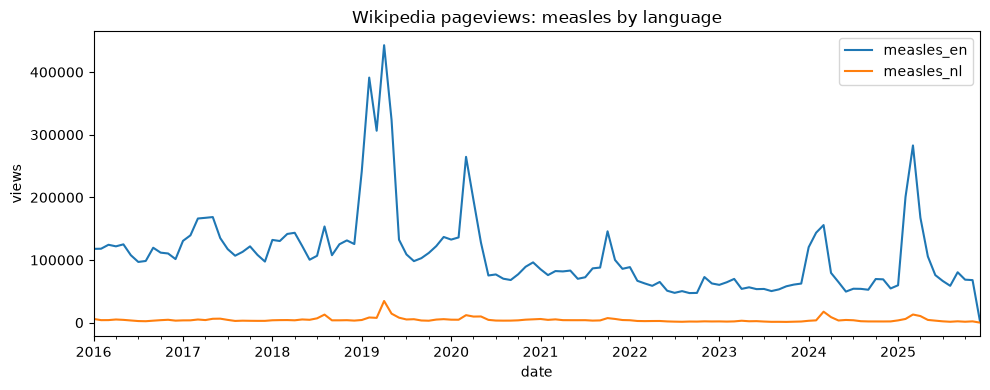

In [2]:
import matplotlib.pyplot as plt

df = get_measles_wiki()
print(f'rows: {len(df)} | range: {df["date"].min().date()} to {df["date"].max().date()}')

ax = df.plot(x='date', y=['measles_en', 'measles_nl'], figsize=(10, 4))
ax.set(title='Wikipedia pageviews: measles by language', xlabel='date', ylabel='views')
plt.tight_layout()
plt.show()


## Step 2: reproducibility

> *Pull the English series twice and report whether the two pulls are identical.*

They should be - the contrast with Google Trends' sampling noise.


In [3]:
try:
    first_pull = wiki_fetch('Measles', 'en.wikipedia')
    second_pull = wiki_fetch('Measles', 'en.wikipedia')
    print(f'Two English measles pulls identical? {first_pull.equals(second_pull)}')
except Exception as error:
    print(f'Live reproducibility check unavailable ({type(error).__name__}): {error}')


Two English measles pulls identical? True


## Step 3: sanity-check and save

> *Report missing values per column and the correlation between the language series,*
> *then save the merged frame to `dengue_wikipedia.csv` and confirm.*


In [4]:
language_columns = ['measles_en', 'measles_nl']
print('Missing values per column:')
print(df[['date', *language_columns]].isna().sum())
print('\nCorrelation between language series:')
print(df[language_columns].corr())

output_path = 'measles_wikipedia.csv'
df.to_csv(output_path, index=False)
print(f'Confirmed: saved {len(df)} rows to {output_path}')


Missing values per column:
date          0
measles_en    0
measles_nl    0
dtype: int64

Correlation between language series:
            measles_en  measles_nl
measles_en    1.000000    0.764418
measles_nl    0.764418    1.000000
Confirmed: saved 120 rows to measles_wikipedia.csv


## Step 3b: Dutch Wikipedia versus Google Trends

> *Compare Dutch Wikipedia views of Mazelen with Netherlands Google Trends for the term*
> *`mazelen` and the Measles topic (`/m/0g2gb`), from 2024-01 through 2026-01-01.*
> *Aggregate weekly Trends data to months before comparing it with Wikipedia.*


Google Trends source: saved search file (term only; no topic series)
Weekly Google Trends rows: 104
Months compared: 24 (2024-01-01 to 2025-12-01)
Monthly correlation:
                   mazelen_wikipedia  mazelen_search
mazelen_wikipedia               1.00            0.95
mazelen_search                  0.95            1.00


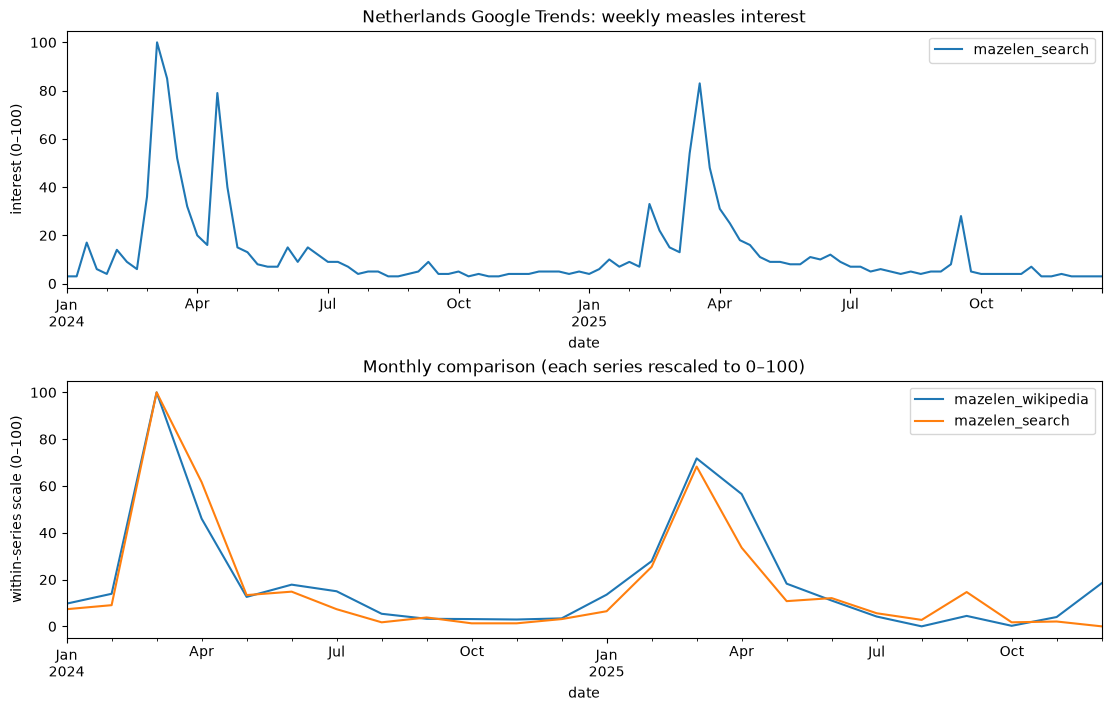

In [6]:
import os
import urllib.parse
import matplotlib.pyplot as plt

GT_START, GT_END = '2024-01', '2026-01'
WIKI_START, WIKI_END = '2024010100', '2026010100'

api_key = os.environ.get('GT_API')
if api_key:
    params = [('key', api_key), ('terms', 'mazelen'), ('terms', '/m/0g2gb'),
              ('restrictions.geo', 'NL'), ('restrictions.startDate', GT_START),
              ('restrictions.endDate', GT_END)]
    gt_url = 'https://www.googleapis.com/trends/v1beta/graph?' + urllib.parse.urlencode(params)
    gt_request = Request(gt_url, headers={'User-Agent': USER_AGENT})
    with urlopen(gt_request, timeout=45) as response:
        gt_lines = json.load(response).get('lines', [])
    if len(gt_lines) != 2:
        raise RuntimeError('Expected one Google Trends line for the term and one for the topic.')

    # API lines retain the request order: Dutch term first, Measles topic second.
    gt_frames = []
    for line in gt_lines:
        frame = pd.DataFrame(line['points'])[['date', 'value']]
        frame['date'] = pd.to_datetime(frame['date'])
        gt_frames.append(frame.set_index('date'))
    nl_gt = pd.concat(gt_frames, axis=1).reset_index()
    nl_gt.columns = ['date', 'mazelen_search', 'measles_topic']
    gt_source = 'live API (term and topic)'
else:
    # The supplied cache contains the Dutch search term, but not the topic series.
    nl_gt = pd.read_csv('../../day1-1530-ai-agents-data-scraping/data/mazelen_NL_search.csv',
                        parse_dates=['date'])
    nl_gt = nl_gt.loc[(nl_gt['date'] >= '2024-01-01') &
                      (nl_gt['date'] < '2026-01-01'), ['date', 'mazelen']]
    nl_gt = nl_gt.rename(columns={'mazelen': 'mazelen_search'})
    gt_source = 'saved search file (term only; no topic series)'

nl_wiki = (wiki_fetch('Mazelen', 'nl.wikipedia', WIKI_START, WIKI_END)
           .rename(columns={'views': 'mazelen_wikipedia'}))
monthly_gt = nl_gt.set_index('date').resample('MS').mean().reset_index()
comparison = nl_wiki.merge(monthly_gt, on='date', how='inner')
series = ['mazelen_wikipedia', *[column for column in nl_gt.columns if column != 'date']]
normalized = comparison.copy()
normalized[series] = comparison[series].apply(
    lambda values: 100 * (values - values.min()) / (values.max() - values.min())
)

print(f'Google Trends source: {gt_source}')
print(f'Weekly Google Trends rows: {len(nl_gt)}')
print(f'Months compared: {len(comparison)} ({comparison.date.min().date()} to '
      f'{comparison.date.max().date()})')
print('Monthly correlation:')
print(comparison[series].corr().round(2))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), constrained_layout=True)
nl_gt.plot(x='date', y=[column for column in nl_gt.columns if column != 'date'], ax=axes[0])
axes[0].set(title='Netherlands Google Trends: weekly measles interest',
            xlabel='date', ylabel='interest (0–100)')
normalized.plot(x='date', y=series, ax=axes[1])
axes[1].set(title='Monthly comparison (each series rescaled to 0–100)',
            xlabel='date', ylabel='within-series scale (0–100)')
plt.show()


## Reflection

- You described outcomes and checks; the agent wrote the API plumbing.
- Wikipedia is the well-behaved stream; the same loop you used on Google Trends works.
- **Stretch:** swap in your own disease/article and languages.
